In [33]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.stats import norm
from scipy.stats import binom
from scipy.stats import poisson

In [2]:
# Load the cleaned dataset
df = pd.read_csv('../data/processed/clean_data.csv')
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AMT_INCOME_TOTAL_OUTLIER,AMT_CREDIT_OUTLIER,AMT_ANNUITY_OUTLIER,DAYS_EMPLOYED_ANOMALY
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,1.0,Normal,Normal,Normal,False
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,Normal,Normal,Normal,False
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,Normal,Normal,Normal,False
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,Normal,Normal,Normal,False
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,Normal,Normal,Normal,False


/var/folders/cp/q_84wgws3850v_xwbw78kpzr0000gp/T/ipykernel_92919/1655137579.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AGE'] = ((df['DAYS_BIRTH'] * -1) / 365).round().astype(int)


                                                                                                                        
AMT_INCOME_TOTAL


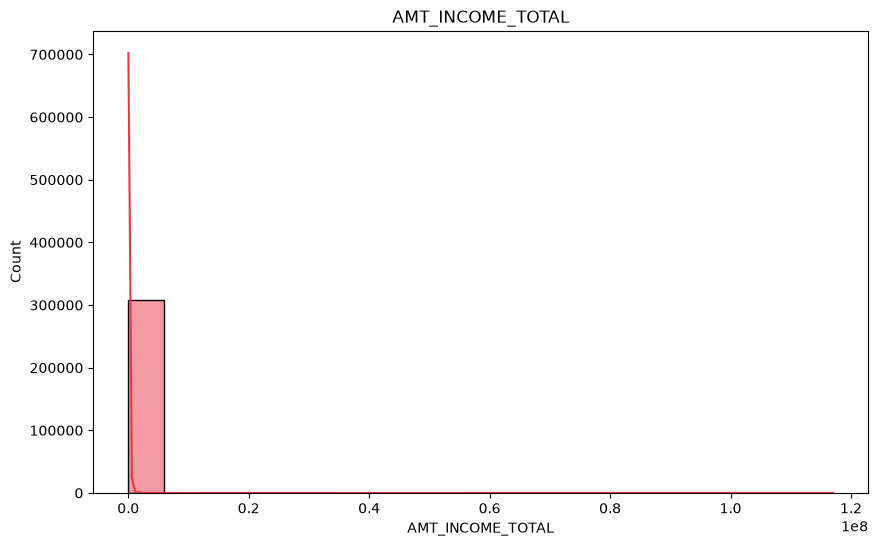

                                                                                                                        
AMT_CREDIT


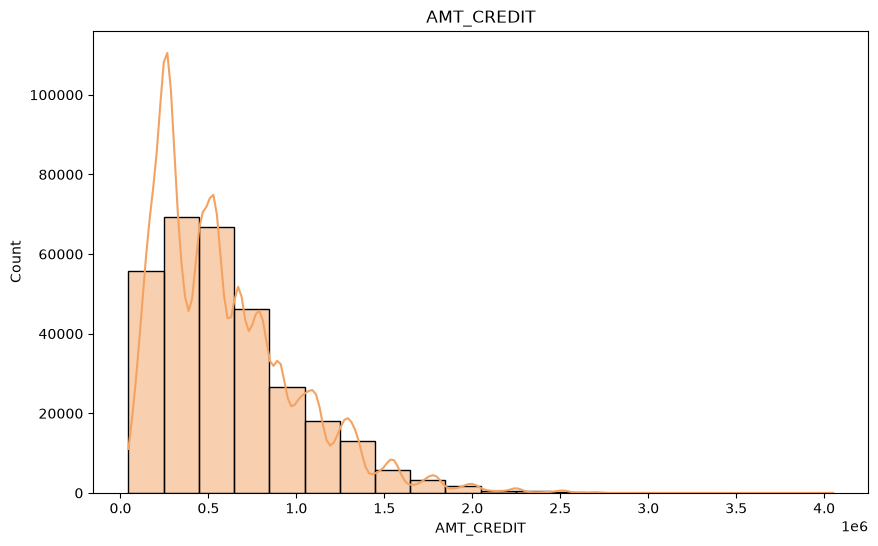

                                                                                                                        
AMT_ANNUITY


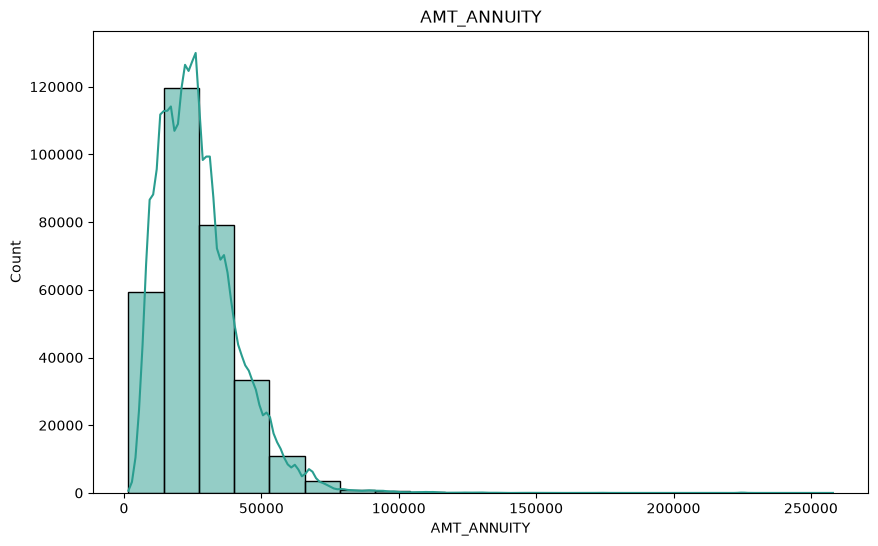

                                                                                                                        
AGE


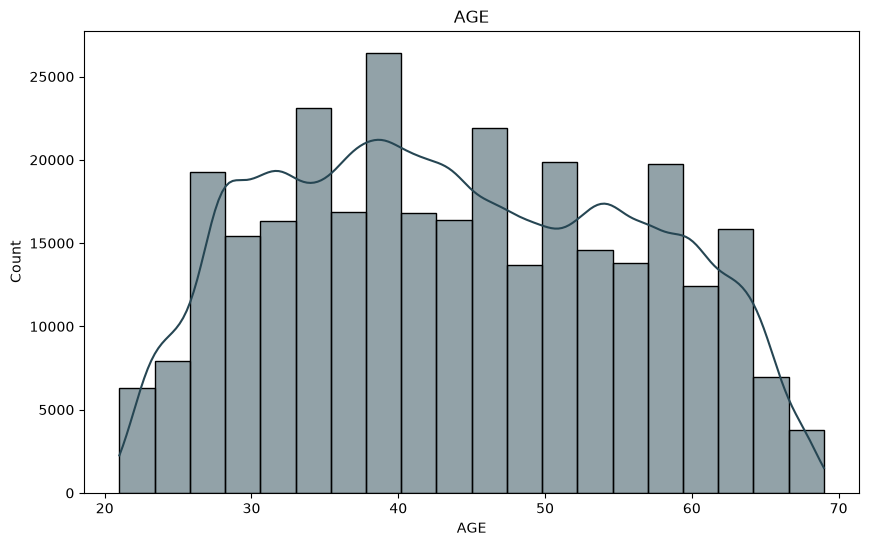

In [3]:
# Test AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, and age (derive age in years from DAYS_BIRTH)
# for normality — plot histogram with KDE overlay for each

# Derive age
df['AGE'] = ((df['DAYS_BIRTH'] * -1) / 365).round().astype(int)
colors = ['#E63946', '#F4A261', '#2A9D8F', '#264653']

# Draw Histogram
features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AGE']

for i, feature in enumerate(features):
    print(" " * 120)
    print("=" * 120)
    print(feature)
    plt.figure(figsize=(10,6))
    sns.histplot(
        df[feature],
        bins=20,
        kde=True,
        color = colors[i]
    )
    plt.title(feature)
    plt.show()

In [10]:
# Calculate skewness AND kurtosis for AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, AGE

# Skewness
from src.utils import skewness_test

features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AGE']

for feature in features:
    print('SKEWNESS')
    print("=" * 50)
    skeweness = skewness_test(df, feature)
    skewness_check = "Right Skewed" if (skeweness > 0) else "Left skewed" if (skeweness < 0) else "Normal"
    print(f"{feature}            {skeweness} ({skewness_check})")
    print(" " * 50)


# Kurtosis
from src.utils import kurtosis_test

print(" " * 60)
print(" " * 60)
print('KURTOSIS')
for feature in features:

    print("=" * 55)
    kurtosis = kurtosis_test(df, feature)
    kurtosis_check = "Leptokurtic" if (kurtosis > 0) else "Platykurtic" if (kurtosis < 0) else "Mesokurtic"
    print(f'{feature}               {kurtosis} ({kurtosis_check})')


SKEWNESS
AMT_INCOME_TOTAL            391.56 (Right Skewed)
                                                  
SKEWNESS
AMT_CREDIT            1.23 (Right Skewed)
                                                  
SKEWNESS
AMT_ANNUITY            1.58 (Right Skewed)
                                                  
SKEWNESS
AGE            0.12 (Right Skewed)
                                                  
                                                            
                                                            
KURTOSIS
AMT_INCOME_TOTAL               191786.55 (Leptokurtic)
AMT_CREDIT               1.93 (Leptokurtic)
AMT_ANNUITY               7.71 (Leptokurtic)
AGE               -1.05 (Platykurtic)


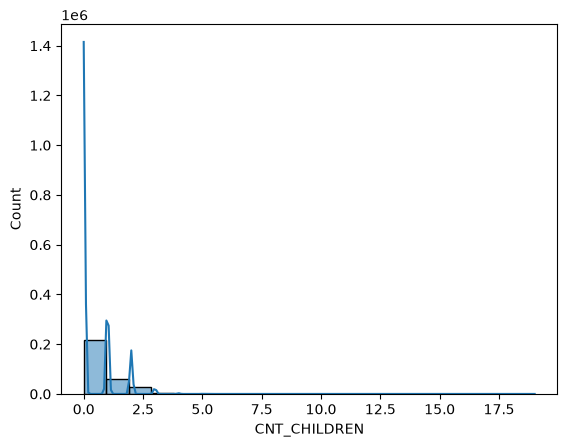

In [14]:
# Check CNT_CHILDREN distribution against a Binomial pattern
# Plot the actual distribution, compare to what a binomial distribution with similar mean would look like

sns.histplot(
    df['CNT_CHILDREN'],
    bins=20,
    kde=True
)
plt.show()

In [19]:
df['CNT_CHILDREN'].value_counts()

CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
14         3
8          2
9          2
12         2
10         2
19         2
11         1
Name: count, dtype: int64

BINOMIAL DISTRIBUTION
k: 0            0.6531
k: 1            0.2842
k: 2            0.0557
k: 3            0.0065
k: 4            0.0005
k: 5            0.0
k: 6            0.0
                         
REAL DISTRIBUTION
CNT_CHILDREN
0    0.700368
1    0.198754
2    0.086986
3    0.012087
4    0.001395
5    0.000273
6    0.000068
Name: proportion, dtype: float64
                                   
COMPARISON


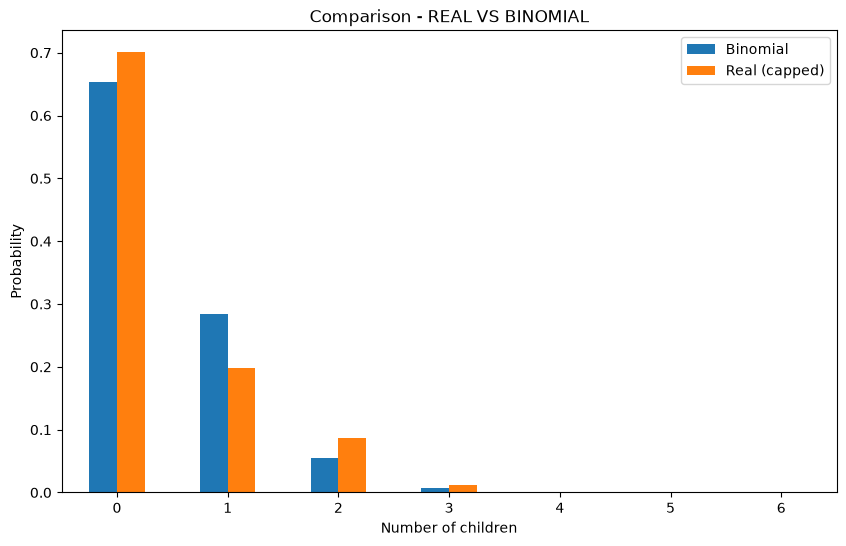

In [127]:
# Check CNT_CHILDREN distribution against a Binomial pattern
# Plot the actual distribution, compare to what a binomial distribution with similar mean would look like

mean = df['CNT_CHILDREN'].mean()
variance  = df['CNT_CHILDREN'].var()

n = (mean ** 2) / (mean - variance) if mean > variance else 10
p = mean/n
k= df['CNT_CHILDREN'].max() if df['CNT_CHILDREN'].max() <= 7 else 7

print('BINOMIAL DISTRIBUTION')
bionom_distribution = {}
bionom_distribution = pd.Series(bionom_distribution)
for i in range(k):
    bionom_prob = scipy.stats.binom.pmf(i,n,p).round(4)  
    bionom_distribution[i] = bionom_prob  
    print("=" * 25)
    print(f'k: {i}            {bionom_prob}')

real_distribution = df['CNT_CHILDREN'].value_counts(normalize=True).sort_index()
real_distribution_capped = real_distribution.loc[0:6]
print(" " * 25)
print("=" * 25)
print("REAL DISTRIBUTION")
print(real_distribution_capped)


print(" " * 35)
print("=" * 35)
print("COMPARISON")
graph = pd.DataFrame({
    "Binomial": bionom_distribution,
    "Real (capped)": real_distribution_capped
})
ax = graph.plot.bar(figsize=(10, 6), rot=0)
ax.set_xlabel("Number of children")
ax.set_ylabel("Probability")
plt.title("Comparison - REAL VS BINOMIAL")
plt.show()

POISSON DISTRIBUTION
k: 0            0.1496
k: 1            0.2842
k: 2            0.27
k: 3            0.171
k: 4            0.0812
k: 5            0.0309
k: 6            0.0098
k: 7            0.0027
k: 8            0.0006
k: 9            0.0001
                         
                         
REAL DISTRIBUTION
AMT_REQ_CREDIT_BUREAU_YEAR
0.0    0.269937
1.0    0.238372
2.0    0.188697
3.0    0.126425
4.0    0.077875
5.0    0.045310
6.0    0.026193
7.0    0.014546
8.0    0.007996
Name: proportion, dtype: float64


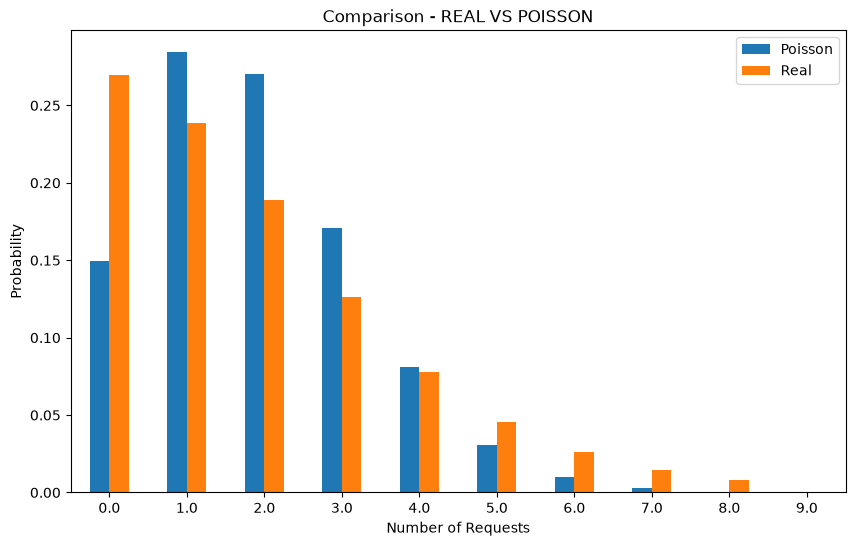

                                                                                                                        

DISTRIBUTION TESTING SUMMARY

Normality Check (AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, AGE):
- AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY are all right-skewed and leptokurtic (heavier
  tails than normal), confirming they are not normally distributed. This matches the outlier
  findings from notebook 2 and justifies using IQR (not Z-score) for outlier detection.
- AGE is the closest to normal among the four (skewness ~0.12, near-symmetric), though it is
  platykurtic (flatter, more spread out than a true normal curve) rather than a clean bell curve.

Binomial Test (CNT_CHILDREN):
- Real data roughly follows the shape of a binomial distribution matched on the same mean, but
  diverges at the extremes. This makes sense: number of children results from family planning
  decisions, not independent random trials, so a perfect fit was never expected.

Poisson Test (AMT_

In [136]:
# Check AMT_REQ_CREDIT_BUREAU_YEAR (number of credit bureau inquiries in past year) against visulization Poisson distribution
# Calculate the mean, generate theoretical Poisson probabilities for k=0 to 8, plot real vs theoretical

import scipy.stats


mean = df["AMT_REQ_CREDIT_BUREAU_YEAR"].mean()
k = 10
poisson_distribution = {}
print("POISSON DISTRIBUTION")
for i in range(k):
    poisson_dist = scipy.stats.poisson.pmf(i,mean).round(4)
    poisson_distribution[i] = poisson_dist
    print("=" * 25)
    print(f'k: {i}            {poisson_dist}')


print(" " * 25)
print(" " * 25)
print("REAL DISTRIBUTION")  
print("=" * 25)
real_distribution = df['AMT_REQ_CREDIT_BUREAU_YEAR'].value_counts(normalize=True).sort_index()
real_distribution_capped = real_distribution.loc[0:8]
print(real_distribution_capped)


# Visulization
visulization = pd.DataFrame({
    "Poisson": poisson_distribution,
    "Real" : real_distribution_capped
})
ax = visulization.plot.bar(figsize=(10, 6), rot=0)
ax.set_xlabel("Number of Requests")
ax.set_ylabel("Probability")
plt.title("Comparison - REAL VS POISSON")
plt.show()

print(" " * 120)
print("=" * 120)
print("""
DISTRIBUTION TESTING SUMMARY

Normality Check (AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, AGE):
- AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY are all right-skewed and leptokurtic (heavier
  tails than normal), confirming they are not normally distributed. This matches the outlier
  findings from notebook 2 and justifies using IQR (not Z-score) for outlier detection.
- AGE is the closest to normal among the four (skewness ~0.12, near-symmetric), though it is
  platykurtic (flatter, more spread out than a true normal curve) rather than a clean bell curve.

Binomial Test (CNT_CHILDREN):
- Real data roughly follows the shape of a binomial distribution matched on the same mean, but
  diverges at the extremes. This makes sense: number of children results from family planning
  decisions, not independent random trials, so a perfect fit was never expected.

Poisson Test (AMT_REQ_CREDIT_BUREAU_YEAR):
- Strongest fit of the three tests. Real data closely tracks the theoretical Poisson curve
  across k=0 to 6, consistent with counting independent inquiry events over a fixed year.

Implication for later analysis:
Since income, credit, and annuity are confirmed non-normal, hypothesis testing in notebook 4
involving these variables should use non-parametric methods rather than tests assuming normality.
""")